In [1]:
from era5 import *

# ==========================================================
# LOAD METADATA
# ==========================================================

(
    place_name,
    target_lat,
    target_lon,
    nearest_lat,
    nearest_lon,
    lat_idx,
    lon_idx,
    pressure_levels,
) = load_metadata(
    r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\metadata_pressure.npz"
)

print("=" * 60)
print(place_name)
print("Target :", target_lat, target_lon)
print("Nearest:", nearest_lat, nearest_lon)
print("Local grid index:", lat_idx, lon_idx)
print("Pressure levels:", pressure_levels)
print("=" * 60)

# ==========================================================
# LOAD PRESSURE DATA
# ==========================================================

(
    valid_time,
    temperature,
    specific_humidity,
    geopotential,
) = load_pressure_dataset(
    r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\pressure_2025.npz",
    lat_idx,
    lon_idx,
)

print("Time shape        :", valid_time.shape)
print("Temperature shape :", temperature.shape)
print("Humidity shape    :", specific_humidity.shape)
print("Geopotential shape:", geopotential.shape)

print()

print("First timestamp :", valid_time[0])
print("Temperature profile:")
print(temperature[0])

print("Specific humidity profile:")
print(specific_humidity[0])

print("Height profile (m):")
print(geopotential[0] / G)

print()

# ==========================================================
# BUILD ONE ATMOSPHERE
# ==========================================================

surface_height = 140.0      # Kanpur DEM (replace later)

row = build_atmosphere(
    temperature,
    specific_humidity,
    geopotential,
    surface_height,
    pressure_levels,
    time_index=0,
)

print("Atmosphere shape:", row.shape)
print(row)

site_26.4967_80.2413
Target : 26.4967 80.2413
Nearest: 26.5 80.25
Local grid index: 2 9
Pressure levels: [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   50.]
Time shape        : (8760,)
Temperature shape : (8760, 13)
Humidity shape    : (8760, 13)
Geopotential shape: (8760, 13)

First timestamp : 2025-01-01T00:00:00.000000000
Temperature profile:
[281.705   282.67084 287.27405 280.3175  272.3416  263.3907  251.15944
 236.28339 225.78334 217.69849 210.21782 204.56367 205.03214]
Specific humidity profile:
[6.8701897e-03 2.8401087e-03 7.1167882e-04 1.0507517e-03 1.6071600e-03
 1.1970318e-03 5.5509241e-04 1.0437643e-04 4.2288892e-05 1.8283994e-05
 6.6300936e-06 2.7318929e-06 3.0429801e-06]
Height profile (m):
[  156.81883   801.6053   1511.096    3128.8499   4377.9746   5809.2505
  7489.036    9543.346   10776.94    12218.622   14022.251   16475.982
 20543.28   ]

Atmosphere shape: (30,)
[  1.  20. 282.  56. 282. 283. 287. 280. 272. 263. 251. 236. 226. 218.
 210

site_26.4967_80.2413
26.4967 80.2413
Surface height = 129.2744140625


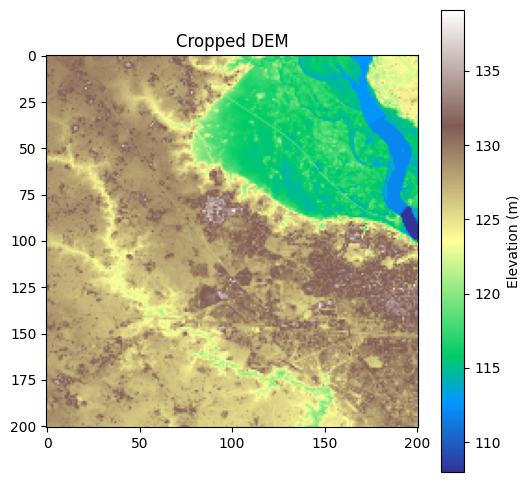

Temperature: (8760, 13)
Humidity: (8760, 13)
MAE  : 0.7767418061834949
RMSE : 0.9980407424410135
Bias : 0.3305656448251355


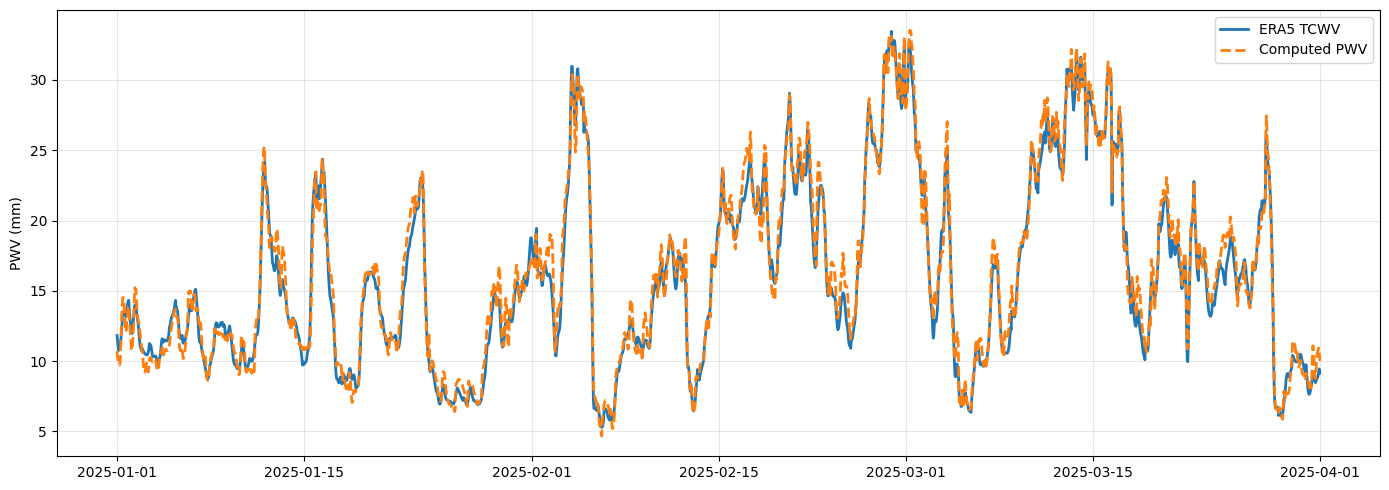

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from dem import *
from era5 import *

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

DEM_PATH = r'C:\Users\Darkrai\Projects\iitk proj\DEMs\Kanpur\Kanpur_90.tif'

META_PATH = BASE + r"\ERA5_DATABASE\site_264967_802413\metadata_pressure.npz"

PRESSURE_PATH = BASE + r"\ERA5_DATABASE\site_264967_802413\pressure_2025.npz"

SINGLE_PATH = BASE + r"\ERA5_DATABASE\site_264967_802413\surface_2025.npz"

# ==========================================================
# LOAD METADATA
# ==========================================================

(
    place_name,
    target_lat,
    target_lon,
    nearest_lat,
    nearest_lon,
    lat_idx,
    lon_idx,
    pressure_levels,
) = load_metadata(META_PATH)

pressure_levels = pressure_levels    # hPa -> Pa

print(place_name)
print(target_lat, target_lon)

# ==========================================================
# DEM
# ==========================================================

dem, transform, bounds = load_dem(DEM_PATH)

cropped_dem, _, _, _ = crop_dem(
    dem,
    transform,
    target_lat,
    target_lon,
    100
)

surface_height = float(
    cropped_dem[
        cropped_dem.shape[0]//2,
        cropped_dem.shape[1]//2
    ]
)

print("Surface height =", surface_height)

plt.figure(figsize=(6,6))
plt.imshow(cropped_dem,cmap='terrain')
plt.colorbar(label="Elevation (m)")
plt.title("Cropped DEM")
plt.show()

# ==========================================================
# ERA5
# ==========================================================

(
    valid_time,
    temperature,
    specific_humidity,
    geopotential,
) = load_pressure_dataset(
    PRESSURE_PATH,
    lat_idx,
    lon_idx,
)

(
    _,
    surface_pressure,
    tcwv,
) = load_single_dataset(
    SINGLE_PATH,
    lat_idx,
    lon_idx,
)

print("Temperature:", temperature.shape)
print("Humidity:", specific_humidity.shape)

# ==========================================================
# PWV
# ==========================================================

N = min(24*90, len(valid_time))      # 3 months

pwv = np.empty(N)

for t in range(N):

    T = temperature[t]

    q = specific_humidity[t]

    z = geopotential[t] / G

    vmr = vmr_from_q(q)

    (
        insert,
        ps,
        ts,
        vs,
    ) = interpolate_surface(
        pressure_levels,
        z,
        T,
        vmr,
        surface_height,
    )

    ratio = (surface_height-z[insert-1])/(z[insert]-z[insert-1])

    qs = (
        q[insert-1]
        +
        ratio*(q[insert]-q[insert-1])
    )

    pwv[t] = compute_pwv(
        q,
        pressure_levels,
        insert,
        ps,
        qs,
    )

# ==========================================================
# STATISTICS
# ==========================================================

err = pwv - tcwv[:N]

print("="*60)

print("MAE  :", np.mean(np.abs(err)))
print("RMSE :", np.sqrt(np.mean(err**2)))
print("Bias :", np.mean(err))

print("="*60)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(14,5))

plt.plot(
    valid_time[:N],
    tcwv[:N],
    lw=2,
    label="ERA5 TCWV"
)

plt.plot(
    valid_time[:N],
    pwv,
    "--",
    lw=2,
    label="Computed PWV"
)

plt.ylabel("PWV (mm)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
for i in np.load(r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\surface_2025.npz"):
    print(i)

valid_time
latitude
longitude
surface_pressure
temperature_2m
tcwv


Prepared benchmark inputs.
CPU loop: 0.360 s
8760/8760
GPU batch: 0.106 s

Maximum difference: 0.001953125
Mean difference: 0.0003390029

Speedup = 3.40x


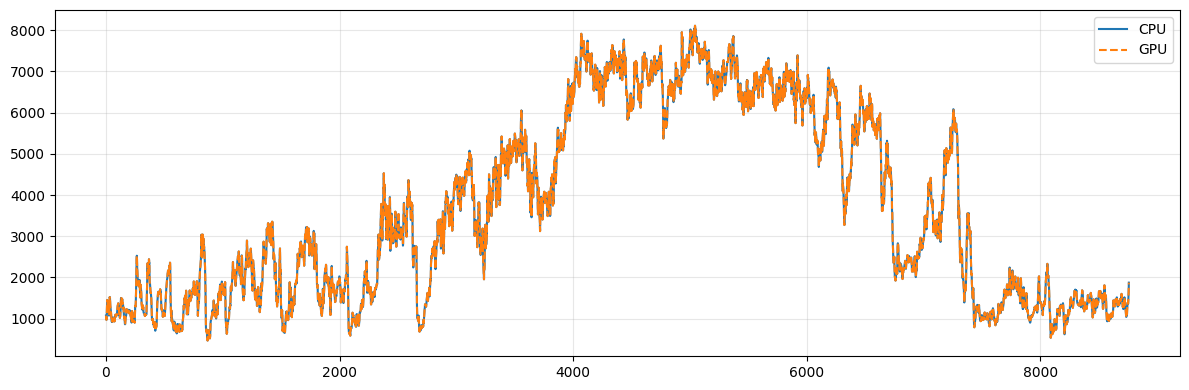

In [ ]:
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from dem import *
from era5 import *

# ==========================================================
# CONFIG
# ==========================================================

N = 8760

# ==========================================================
# LOAD DATA
# ==========================================================

(
    place_name,
    target_lat,
    target_lon,
    nearest_lat,
    nearest_lon,
    lat_idx,
    lon_idx,
    pressure_levels,
) = load_metadata(META_PATH)

pressure_levels = pressure_levels * 100.0

(
    valid_time,
    temperature,
    specific_humidity,
    geopotential,
) = load_pressure_dataset(
    PRESSURE_PATH,
    lat_idx,
    lon_idx,
)

dem, transform, bounds = load_dem(DEM_PATH)

cropped_dem, _, _, _ = crop_dem(
    dem,
    transform,
    target_lat,
    target_lon,
)

surface_height = float(
    cropped_dem[
        cropped_dem.shape[0]//2,
        cropped_dem.shape[1]//2
    ]
)

# ==========================================================
# BUILD GPU INPUTS
# ==========================================================

insert_idx = np.empty((N,1,1),dtype=np.int32)
surface_pressure = np.empty((N,1,1),dtype=np.float32)
ratio = np.empty((N,1,1),dtype=np.float32)

pwv_loop = np.empty(N,dtype=np.float32)

for t in range(N):

    T = temperature[t]

    q = specific_humidity[t]

    z = geopotential[t]/G

    vmr = vmr_from_q(q)

    insert,ps,ts,vs = interpolate_surface(
        pressure_levels,
        z,
        T,
        vmr,
        surface_height,
    )

    r = (
        surface_height-z[insert-1]
    )/(
        z[insert]-z[insert-1]
    )

    qs = q[insert-1] + r*(q[insert]-q[insert-1])

    insert_idx[t,0,0] = insert
    surface_pressure[t,0,0] = ps
    ratio[t,0,0] = r

    pwv_loop[t] = compute_pwv(
        q,
        pressure_levels,
        insert,
        ps,
        qs,
    )

print("Prepared benchmark inputs.")

# ==========================================================
# CPU BENCHMARK
# ==========================================================

t0 = time.perf_counter()

pwv_cpu = np.empty(N,dtype=np.float32)

for t in range(N):

    T = temperature[t]

    q = specific_humidity[t]

    z = geopotential[t]/G

    vmr = vmr_from_q(q)

    insert,ps,ts,vs = interpolate_surface(
        pressure_levels,
        z,
        T,
        vmr,
        surface_height,
    )

    r = (
        surface_height-z[insert-1]
    )/(
        z[insert]-z[insert-1]
    )

    qs = q[insert-1] + r*(q[insert]-q[insert-1])

    pwv_cpu[t] = compute_pwv(
        q,
        pressure_levels,
        insert,
        ps,
        qs,
    )

cpu_time = time.perf_counter()-t0

print(f"CPU loop: {cpu_time:.3f} s")

# ==========================================================
# GPU BENCHMARK
# ==========================================================

q_gpu = cp.asarray(
    specific_humidity[:N]
)

insert_gpu = cp.asarray(
    insert_idx
)

ps_gpu = cp.asarray(
    surface_pressure
)

ratio_gpu = cp.asarray(
    ratio
)

cp.cuda.Stream.null.synchronize()

t0 = time.perf_counter()

pwv_gpu, qs_gpu = compute_pwv_dataset(
    q_gpu,
    pressure_levels,
    insert_gpu,
    ps_gpu,
    ratio_gpu,
)

cp.cuda.Stream.null.synchronize()

gpu_time = time.perf_counter()-t0

print(f"GPU batch: {gpu_time:.3f} s")

# ==========================================================
# ACCURACY
# ==========================================================

pwv_gpu = pwv_gpu[:,0,0]

print()

print("Maximum difference:",
      np.max(np.abs(pwv_cpu-pwv_gpu)))

print("Mean difference:",
      np.mean(np.abs(pwv_cpu-pwv_gpu)))

# ==========================================================
# SPEEDUP
# ==========================================================

print()

print(f"Speedup = {cpu_time/gpu_time:.2f}x")

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(12,4))

plt.plot(
    pwv_cpu,
    label="CPU"
)

plt.plot(
    pwv_gpu,
    "--",
    label="GPU"
)

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

DEM shape: (801, 801)
Elevation range: 92.0 147.84969

Horizon computed in 52.839 s
Max zenith computed in 2.088397 s
Saved horizon products to C:\Users\Darkrai\Projects\iitk proj\horizon_test

Loaded back successfully.
Horizon shape: (801, 801, 360)
Max zenith shape: (801, 801, 360)

Horizon identical: True
Max zenith identical: True


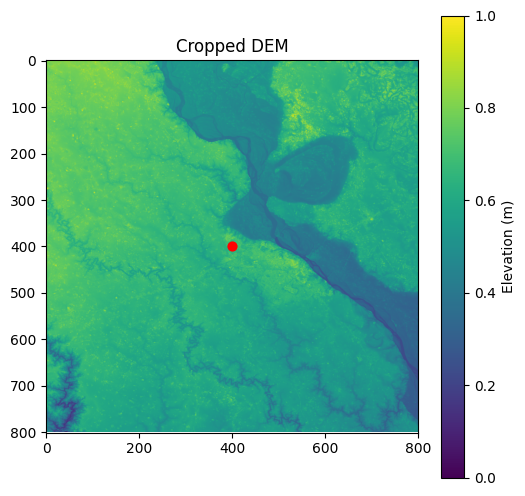

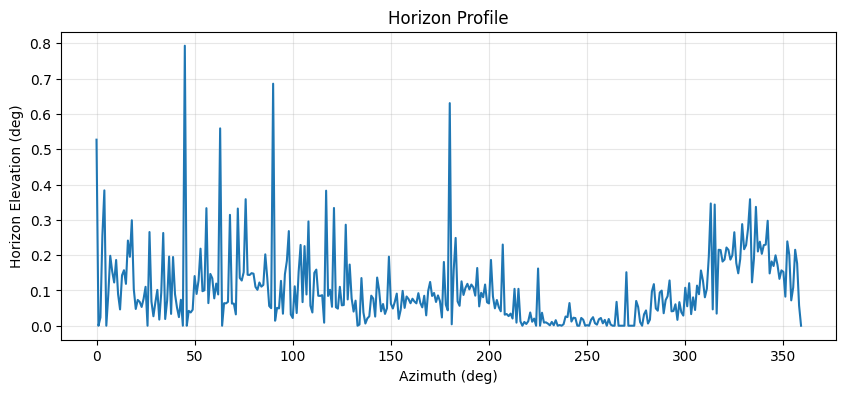

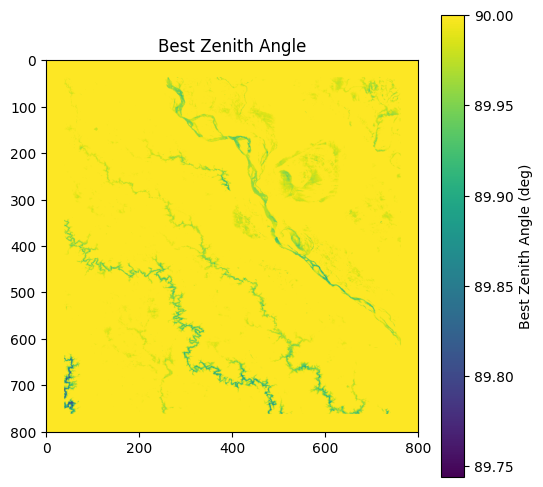


========== SUMMARY ==========
Horizon time     : 52.839 s
Zenith time      : 2.088397 s
Total            : 54.928 s
DEM size         : (801, 801)
Horizon cube     : (801, 801, 360)


In [3]:
import time
import matplotlib.pyplot as plt
import numpy as np

from dem import *

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

DEM_PATH = r'C:\Users\Darkrai\Projects\iitk proj\DEMs\Kanpur\Kanpur_90.tif'

OUT_DIR = BASE + r"\horizon_test"

TARGET_LAT = 26.4967
TARGET_LON = 80.2413

# ==========================================================
# LOAD DEM
# ==========================================================

dem, transform, bounds = load_dem(DEM_PATH)

cropped_dem, new_transform, row, col = crop_dem(
    dem,
    transform,
    TARGET_LAT,
    TARGET_LON,
    half_length=400,
)

print("DEM shape:", cropped_dem.shape)
print("Elevation range:",
      np.nanmin(cropped_dem),
      np.nanmax(cropped_dem))

# ==========================================================
# COMPUTE HORIZON
# ==========================================================

t0 = time.perf_counter()

horizon = compute_horizon(
    cropped_dem,
    pixel_size_m=90.0,
    n_az=360,
    earth_radius_m=6371000.0,
    use_curvature=True,
)

horizon_time = time.perf_counter() - t0

print(f"\nHorizon computed in {horizon_time:.3f} s")

# ==========================================================
# COMPUTE MAX ZENITH
# ==========================================================

t0 = time.perf_counter()

max_zenith, best_zenith, min_horizon = compute_max_zenith(
    horizon
)

zenith_time = time.perf_counter() - t0

print(f"Max zenith computed in {zenith_time:.6f} s")

# ==========================================================
# SAVE
# ==========================================================

save_horizon(
    OUT_DIR,
    horizon,
    max_zenith,
    min_horizon,best_zenith
)

# ==========================================================
# LOAD BACK
# ==========================================================

(
    horizon2,
    max_zenith2,
    min_horizon2,
    best_zenith2,
) = load_horizon(OUT_DIR)

print("\nLoaded back successfully.")

print("Horizon shape:", horizon2.shape)
print("Max zenith shape:", max_zenith2.shape)

print()

print(
    "Horizon identical:",
    np.allclose(horizon, horizon2)
)

print(
    "Max zenith identical:",
    np.allclose(max_zenith, max_zenith2)
)

# ==========================================================
# VISUALIZATION
# ==========================================================

center_i = cropped_dem.shape[0] // 2
center_j = cropped_dem.shape[1] // 2

plt.figure(figsize=(6,6))

plt.imshow(cropped_dem)

plt.scatter(
    center_j,
    center_i,
    c="red",
    s=40,
)

plt.title("Cropped DEM")

plt.colorbar(label="Elevation (m)")

plt.show()

plt.figure(figsize=(10,4))

plt.plot(
    horizon[
        center_i,
        center_j
    ]
)

plt.xlabel("Azimuth (deg)")

plt.ylabel("Horizon Elevation (deg)")

plt.title("Horizon Profile")

plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(6,6))

plt.imshow(best_zenith)

plt.colorbar(label="Best Zenith Angle (deg)")

plt.title("Best Zenith Angle")

plt.show()

# ==========================================================
# SUMMARY
# ==========================================================

print("\n========== SUMMARY ==========")

print(f"Horizon time     : {horizon_time:.3f} s")
print(f"Zenith time      : {zenith_time:.6f} s")
print(f"Total            : {horizon_time+zenith_time:.3f} s")

print(f"DEM size         : {cropped_dem.shape}")
print(f"Horizon cube     : {horizon.shape}")

print("=============================")

DEM shape: (101, 101)

Running exact algorithm...
Exact time : 3.885 s

Running fast algorithm...
Fast time : 1.975 s

Maximum error : 6.6935425 deg
Mean error    : 0.3599865 deg
RMSE          : 0.6066304 deg

Speedup = 1.97x


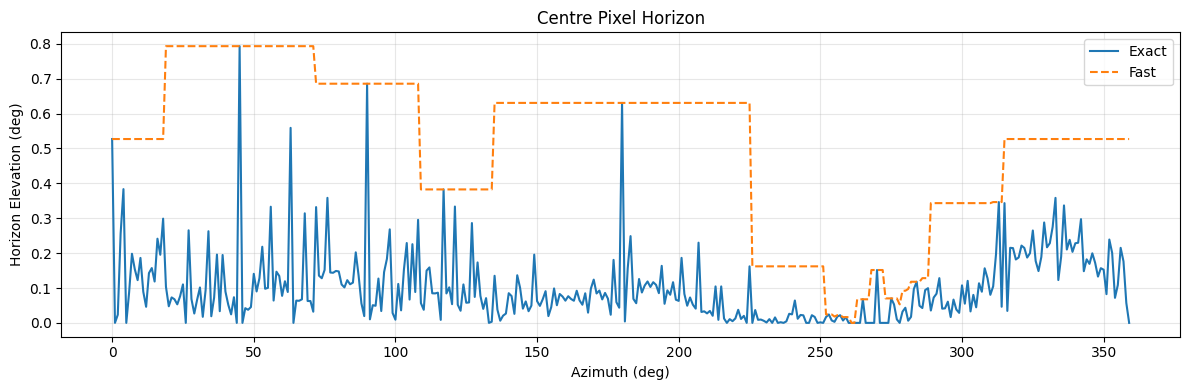

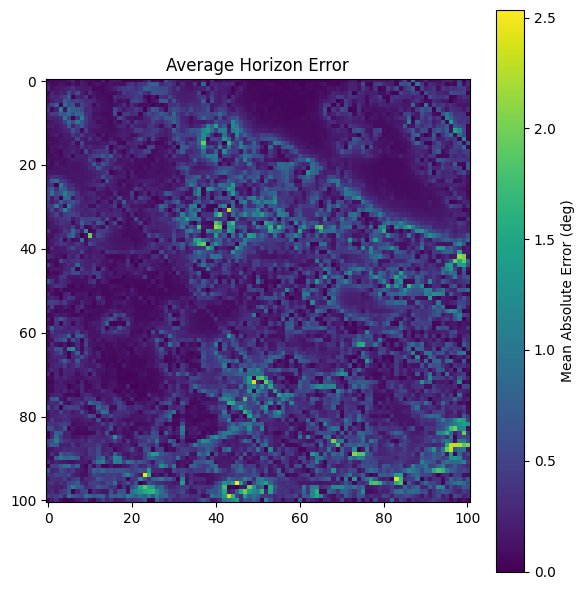


Worst pixel: (np.int64(96), np.int64(45))
Mean error : 2.5348034 deg


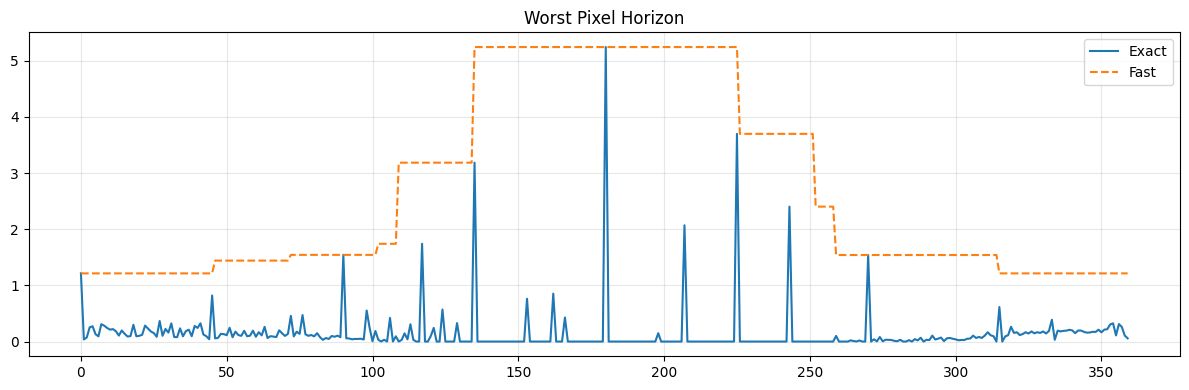

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from dem import *

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

DEM_PATH = r'C:\Users\Darkrai\Projects\iitk proj\DEMs\Kanpur\Kanpur_90.tif'

TARGET_LAT = 26.4967
TARGET_LON = 80.2413

# ==========================================================
# LOAD DEM
# ==========================================================

dem, transform, bounds = load_dem(DEM_PATH)

cropped_dem, _, _, _ = crop_dem(
    dem,
    transform,
    TARGET_LAT,
    TARGET_LON,
    half_length=50,
)

print("DEM shape:", cropped_dem.shape)
print()

# ==========================================================
# EXACT
# ==========================================================

print("Running exact algorithm...")

t0 = time.perf_counter()

horizon_exact = compute_horizon(
    cropped_dem,
    pixel_size_m=90.0,
    n_az=360,
    use_curvature=True,
)

exact_time = time.perf_counter() - t0

print(f"Exact time : {exact_time:.3f} s")

# ==========================================================
# FAST
# ==========================================================

print("\nRunning fast algorithm...")

t0 = time.perf_counter()

horizon_fast = compute_horizon_fast(
    cropped_dem,
    pixel_size_m=90.0,
    n_az=360,
    use_curvature=True,
)

fast_time = time.perf_counter() - t0

print(f"Fast time : {fast_time:.3f} s")

# ==========================================================
# ERROR
# ==========================================================

diff = horizon_fast - horizon_exact

mask = ~np.isnan(diff)

diff = diff[mask]

print("\n==============================")

print("Maximum error :", np.max(np.abs(diff)), "deg")
print("Mean error    :", np.mean(np.abs(diff)), "deg")
print("RMSE          :", np.sqrt(np.mean(diff**2)), "deg")

print()

print(f"Speedup = {exact_time/fast_time:.2f}x")

print("==============================")

# ==========================================================
# VISUALIZATION
# ==========================================================

i = cropped_dem.shape[0] // 2
j = cropped_dem.shape[1] // 2

plt.figure(figsize=(12,4))

plt.plot(
    horizon_exact[i,j],
    label="Exact",
)

plt.plot(
    horizon_fast[i,j],
    "--",
    label="Fast",
)

plt.xlabel("Azimuth (deg)")
plt.ylabel("Horizon Elevation (deg)")
plt.title("Centre Pixel Horizon")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# ERROR MAP
# ==========================================================

error_map = np.nanmean(
    np.abs(horizon_fast - horizon_exact),
    axis=2,
)

plt.figure(figsize=(6,6))

plt.imshow(error_map)

plt.colorbar(label="Mean Absolute Error (deg)")

plt.title("Average Horizon Error")

plt.tight_layout()

plt.show()

# ==========================================================
# WORST PIXEL
# ==========================================================

worst = np.nanargmax(error_map)

r, c = np.unravel_index(
    worst,
    error_map.shape,
)

print()

print("Worst pixel:", (r, c))
print("Mean error :", error_map[r,c], "deg")

plt.figure(figsize=(12,4))

plt.plot(
    horizon_exact[r,c],
    label="Exact",
)

plt.plot(
    horizon_fast[r,c],
    "--",
    label="Fast",
)

plt.title("Worst Pixel Horizon")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [1]:
import numpy as np

from atmosphere import build_amc,save_amc
from era5 import *

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

META_PATH = BASE + r"\ERA5_DATABASE\site_264967_802413\metadata_pressure.npz"

PRESSURE_PATH = BASE + r"\ERA5_DATABASE\site_264967_802413\pressure_2025.npz"

# ==========================================================
# LOAD DATA
# ==========================================================

(
    place_name,
    target_lat,
    target_lon,
    nearest_lat,
    nearest_lon,
    lat_idx,
    lon_idx,
    pressure_levels,
) = load_metadata(META_PATH)



(
    valid_time,
    temperature,
    specific_humidity,
    geopotential,
) = load_pressure_dataset(
    PRESSURE_PATH,
    lat_idx,
    lon_idx,
)

# ==========================================================
# BUILD ONE ATMOSPHERE
# ==========================================================

time_index = 0

surface_height = 130.0      # metres

T = temperature[time_index]

q = specific_humidity[time_index]

z = geopotential[time_index] / G

vmr = vmr_from_q(q)

(
    insert,
    ps,
    ts,
    vs,
) = interpolate_surface(
    pressure_levels,
    z,
    T,
    vmr,
    surface_height,
)

# ==========================================================
# BUILD AMC
# ==========================================================

amc = build_amc(
    pressure_levels=pressure_levels,
    temperature=T,
    vmr=vmr*9,
    insert_idx=insert,
    surface_pressure=ps,
    surface_temperature=ts,
    surface_vmr=vs,
    lwp=0.25,
    iwp=0.05,
    ozone=None,
    title="Test Atmosphere",
    zenith_angle=0.0
)

# ==========================================================
# PRINT
# ==========================================================
save_amc(BASE+r'\amc1.amc',amc)
print("=" * 80)
print(amc)
print("=" * 80)

print()

print("Number of lines :", len(amc.splitlines()))
print("Number of layers:", amc.count("layer"))
print("Contains H2O    :", "column h2o" in amc)
print("Contains LWP    :", "column lwp" in amc)
print("Contains IWP    :", "column iwp" in amc)

# Test Atmosphere

f 2 GHz 14 GHz 0.039993653 GHz
output f GHz tx Tb K
T0 2.7 K
za 0 deg

layer
Pbase 5000.00 Pa
Tbase 205.032 K
column dry_air hydrostatic
column h2o vmr 4.40301774e-05

layer
Pbase 10000.00 Pa
Tbase 204.564 K
column dry_air hydrostatic
column h2o vmr 3.95289317e-05

layer
Pbase 15000.00 Pa
Tbase 210.218 K
column dry_air hydrostatic
column h2o vmr 9.59334429e-05

layer
Pbase 20000.00 Pa
Tbase 217.698 K
column dry_air hydrostatic
column h2o vmr 2.64556467e-04

layer
Pbase 25000.00 Pa
Tbase 225.783 K
column dry_air hydrostatic
column h2o vmr 6.11881434e-04

layer
Pbase 30000.00 Pa
Tbase 236.283 K
column dry_air hydrostatic
column h2o vmr 1.51017401e-03

layer
Pbase 40000.00 Pa
Tbase 251.159 K
column dry_air hydrostatic
column h2o vmr 8.02917592e-03

layer
Pbase 50000.00 Pa
Tbase 263.391 K
column dry_air hydrostatic
column h2o vmr 1.73078068e-02

layer
Pbase 60000.00 Pa
Tbase 272.342 K
column dry_air hydrostatic
column h2o vmr 2.32320372e-02

layer
Pbase 70000.00 Pa
Tbase

Loaded 300 frequency points.


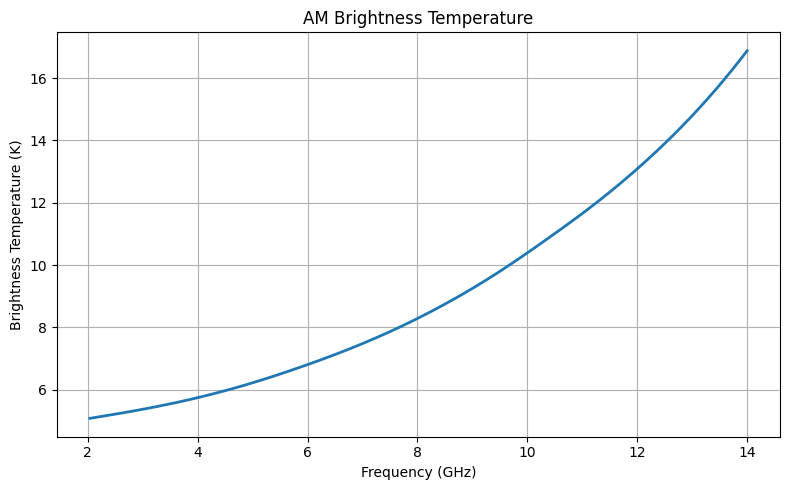

In [2]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PATHS
# ==========================================================

AM_EXE = r"am.exe"
AMC_FILE = r"C:\Users\Darkrai\Projects\iitk proj\amc1.amc"

# ==========================================================
# RUN AM
# ==========================================================

result = subprocess.run(
    [AM_EXE, AMC_FILE],
    capture_output=True,
    text=True,
)

# ==========================================================
# PARSE OUTPUT
# ==========================================================

freq = []
tx = []
tb = []

for line in result.stdout.splitlines():

    line = line.strip()

    if not line:
        continue

    if line.startswith("#"):
        continue

    if line.startswith("!"):
        continue

    parts = line.split()

    if len(parts) < 3:
        continue

    try:
        freq.append(float(parts[0]))
        tx.append(float(parts[1]))
        tb.append(float(parts[2]))
    except ValueError:
        pass

freq = np.asarray(freq)
tx = np.asarray(tx)
tb = np.asarray(tb)

print(f"Loaded {len(freq)} frequency points.")

# ==========================================================
# PLOT BRIGHTNESS TEMPERATURE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    freq,
    tb,
    linewidth=2,
)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Brightness Temperature (K)")
plt.title("AM Brightness Temperature")

plt.grid(True)

plt.tight_layout()

plt.show()

Running AM...
AM completed with warnings
2.039676e+00 9.910468e-01 5.082828e+00
2.079670e+00 9.910048e-01 5.094368e+00
2.119664e+00 9.909628e-01 5.105897e+00
2.159657e+00 9.909208e-01 5.117427e+00
2.199651e+00 9.908788e-01 5.128969e+00
2.239645e+00 9.908366e-01 5.140532e+00
2.279638e+00 9.907944e-01 5.152124e+00
2.319632e+00 9.907520e-01 5.163755e+00
2.359626e+00 9.907095e-01 5.175431e+00
2.399619e+00 9.906667e-01 5.187159e+00
2.439613e+00 9.906238e-01 5.198946e+00
2.479606e+00 9.905806e-01 5.210796e+00
2.519600e+00 9.905372e-01 5.222717e+00
2.559594e+00 9.904934e-01 5.234713e+00
2.599587e+00 9.904494e-01 5.246791e+00
2.639581e+00 9.904051e-01 5.258953e+00
2.679575e+00 9.903604e-01 5.271206e+00
2.719568e+00 9.903154e-01 5.283552e+00
2.759562e+00 9.902701e-01 5.295997e+00
2.799556e+00 9.902244e-01 5.308543e+00
2.839549e+00 9.901782e-01 5.321195e+00
2.879543e+00 9.901317e-01 5.333956e+00
2.919537e+00 9.900848e-01 5.346829e+00
2.959530e+00 9.900375e-01 5.359817e+00
2.999524e+00 9.899897e-

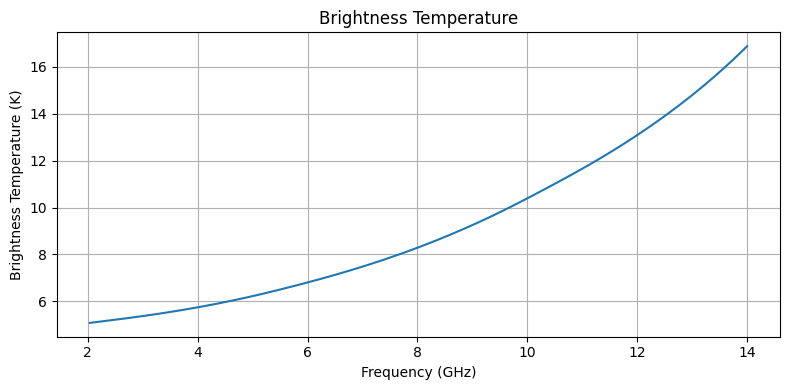

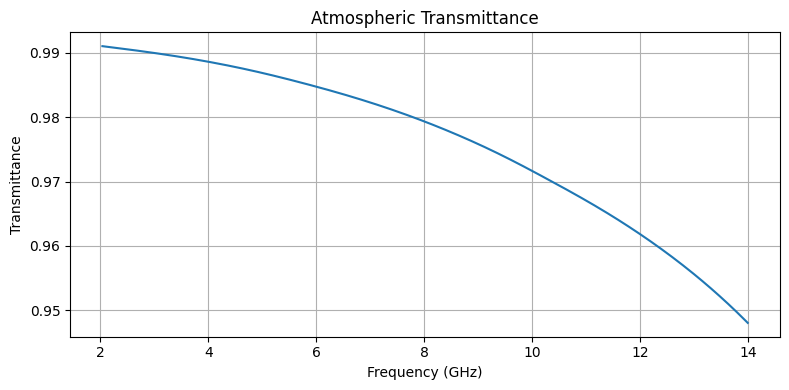


SUMMARY
AM runtime        : 0.036 s
Spectrum points   : 300
Frequency range   : 2.040 - 13.998 GHz
Tb range          : 5.083 - 16.881 K
Tx range          : 0.948012 - 0.991047


In [3]:
import time
import matplotlib.pyplot as plt

from am import *

# ==========================================================
# PATHS
# ==========================================================

AM_EXE = r"am.exe"

AMC_FILE = r"C:\Users\Darkrai\Projects\iitk proj\amc1.amc"

OUTPUT = r"C:\Users\Darkrai\Projects\iitk proj\spectrum_test.npz"

# ==========================================================
# RUN AM
# ==========================================================

print("=" * 60)
print("Running AM...")
print("=" * 60)

t0 = time.perf_counter()

frequency, transmittance, brightness_temperature = run_am(
    AM_EXE,
    AMC_FILE,
)

runtime = time.perf_counter() - t0

print(f"Execution time : {runtime:.3f} s")
print()

# ==========================================================
# BASIC CHECKS
# ==========================================================

print("=" * 60)
print("Spectrum Diagnostics")
print("=" * 60)

print("Frequency points :", len(frequency))
print("Frequency range  :", frequency.min(), "to", frequency.max(), "GHz")
print()

print("Transmittance")
print("  Min :", transmittance.min())
print("  Max :", transmittance.max())

print()

print("Brightness Temperature")
print("  Min :", brightness_temperature.min(), "K")
print("  Max :", brightness_temperature.max(), "K")

print()

assert len(frequency) == len(transmittance)
assert len(frequency) == len(brightness_temperature)

assert np.all(np.isfinite(frequency))
assert np.all(np.isfinite(transmittance))
assert np.all(np.isfinite(brightness_temperature))

print("✓ Array checks passed")

# ==========================================================
# SAVE / LOAD TEST
# ==========================================================

print()
print("=" * 60)
print("Testing save/load...")
print("=" * 60)

save_spectrum(
    OUTPUT,
    frequency,
    transmittance,
    brightness_temperature,
)

(
    frequency2,
    transmittance2,
    brightness_temperature2,
    stdout,
) = load_spectrum(OUTPUT)

print("Frequency identical :", np.allclose(frequency, frequency2))
print("Tx identical        :", np.allclose(transmittance, transmittance2))
print("Tb identical        :", np.allclose(brightness_temperature,
                                           brightness_temperature2))

print()

# ==========================================================
# PLOTS
# ==========================================================

plt.figure(figsize=(8,4))
plt.plot(
    frequency,
    brightness_temperature,
)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Brightness Temperature (K)")
plt.title("Brightness Temperature")
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(8,4))
plt.plot(
    frequency,
    transmittance,
)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmittance")
plt.title("Atmospheric Transmittance")
plt.grid(True)
plt.tight_layout()

plt.show()

# ==========================================================
# SUMMARY
# ==========================================================

print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"AM runtime        : {runtime:.3f} s")
print(f"Spectrum points   : {len(frequency)}")
print(f"Frequency range   : {frequency.min():.3f} - {frequency.max():.3f} GHz")
print(f"Tb range          : {brightness_temperature.min():.3f} - {brightness_temperature.max():.3f} K")
print(f"Tx range          : {transmittance.min():.6f} - {transmittance.max():.6f}")
print("=" * 60)